In [28]:
import os
print(os.getcwd())

d:\NeuroGuard\notebooks


In [29]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [30]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.data.load_data import(
    load_config, load_dataset
)

from ml.data.validate import DatasetValidator

sns.set_theme(style='whitegrid')

FIGURE_DIR = Path("..artifacts/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [31]:
config = load_config("../configs/config.yaml")

df = load_dataset(config)

validator = DatasetValidator(df)

report = validator.generate_report(
    config["model"]["target"]
)

2026-07-07 14:51:26,360 | INFO | Configuation loaded successfully.
2026-07-07 14:51:26,360 | INFO | Loading dataset: 
D:\NeuroGuard\ml\data\raw\stroke_data.csv
2026-07-07 14:51:26,369 | INFO | Dataset loaded successfully.



DATA VALIDATION REPORT

Dataset Shape
{'rows': 5110, 'columns': 12}

Duplicate Rows
0

Missing Values
                   Missing Count  Missing %
bmi                          201       3.93
id                             0       0.00
age                            0       0.00
gender                         0       0.00
hypertension                   0       0.00
heart_disease                  0       0.00
work_type                      0       0.00
ever_married                   0       0.00
Residence_type                 0       0.00
avg_glucose_level              0       0.00
smoking_status                 0       0.00
stroke                         0       0.00

Data Types
                  Data Type  Non Null  Unique
id                    int64      5110    5110
gender                  str      5110       3
age                 float64      5110     104
hypertension          int64      5110       2
heart_disease         int64      5110       2
ever_married            str      5110

In [32]:
display(df.head()) # gives top 5 rows
display(df.sample(5)) # random 5 rows
display(df.describe()) # statistical data
display(df.info()) # data-type and total-entries

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3908,11208,Female,2.0,0,0,No,children,Rural,70.25,17.0,Unknown,0
2349,56312,Male,47.0,0,0,No,Private,Rural,111.15,23.8,never smoked,0
1448,49341,Female,78.0,0,0,Yes,Private,Rural,154.75,17.6,never smoked,0
347,17608,Female,55.0,0,0,Yes,Govt_job,Urban,118.82,29.0,formerly smoked,0
4717,68417,Female,19.0,0,0,No,Private,Rural,66.70,24.7,never smoked,0


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


None

,Missing Count,Missing %
bmi,201,3.93
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00


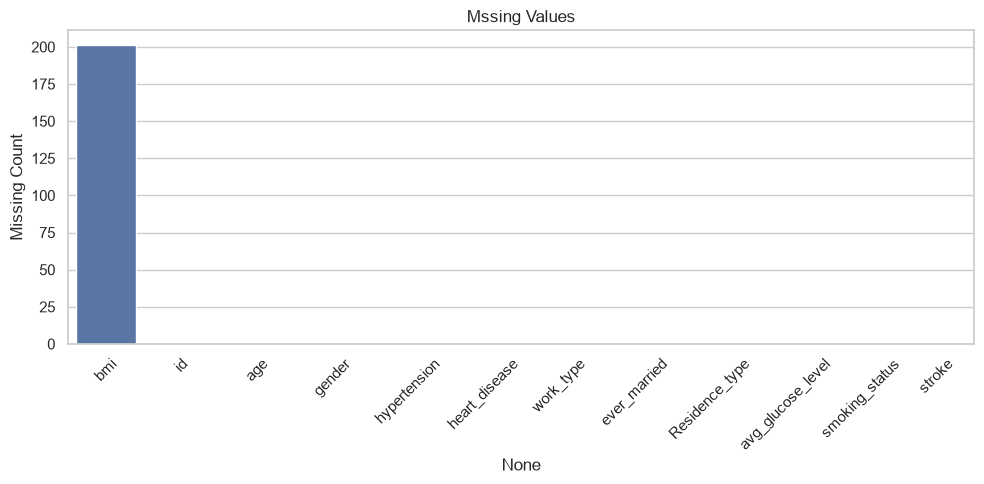

In [33]:
missing = report["missing"]
display(missing)
plt.figure(figsize=(10, 5))
sns.barplot(
    x = missing.index,
    y = missing["Missing Count"]
)
plt.xticks(rotation = 45)
plt.title("Mssing Values")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "missing_value.png")
plt.show()

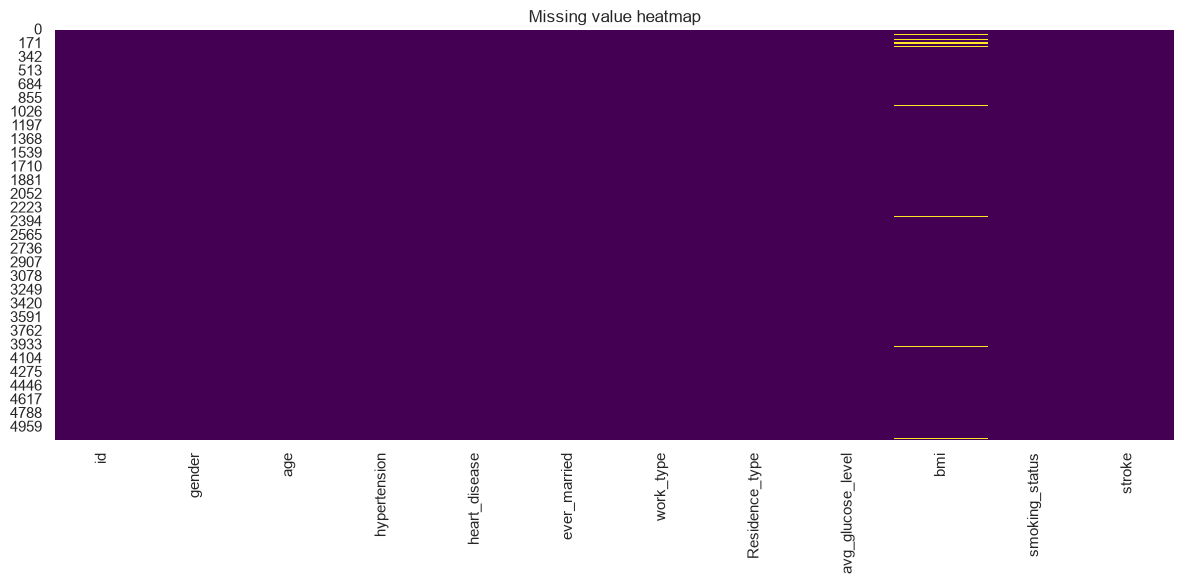

In [34]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.isnull(),
    cbar = False,
    cmap='viridis'
)

plt.title("Missing value heatmap")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "missing_heatmap.png")
plt.show()

2026-07-07 14:51:27,246 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 14:51:27,252 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


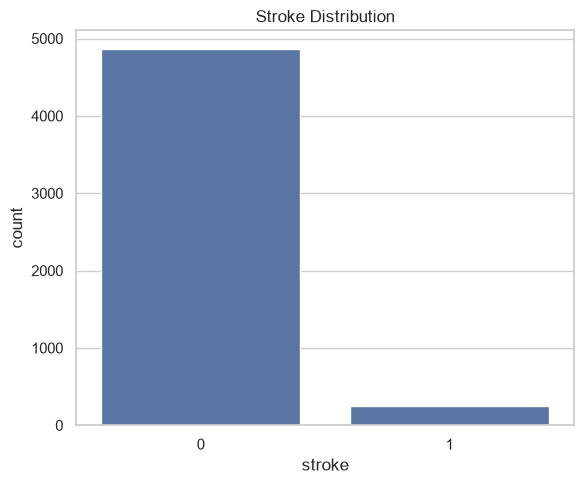

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [35]:
plt.figure(figsize=(6, 5))
sns.countplot(
    data = df,
    x = "stroke"
)

plt.title("Stroke Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'stroke_distribution.png')
plt.show()

print(df['stroke'].value_counts(normalize=True)*100)

In [36]:
TARGET = "stroke"
ID_COLUMN = "id"

numeric_cols = [
    col
    for col in df.select_dtypes(include=np.number).columns
    if col not in [ID_COLUMN, TARGET]
]

numeric_cols

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

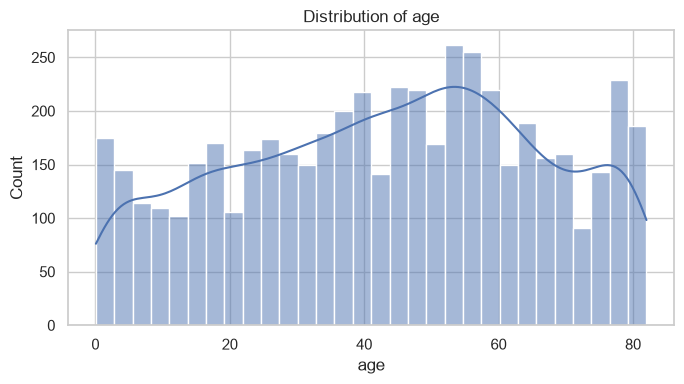

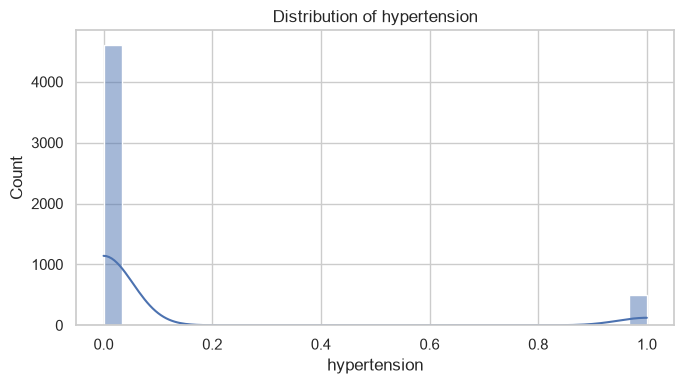

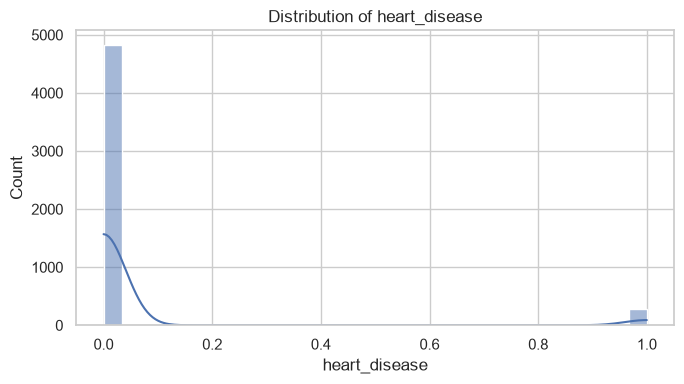

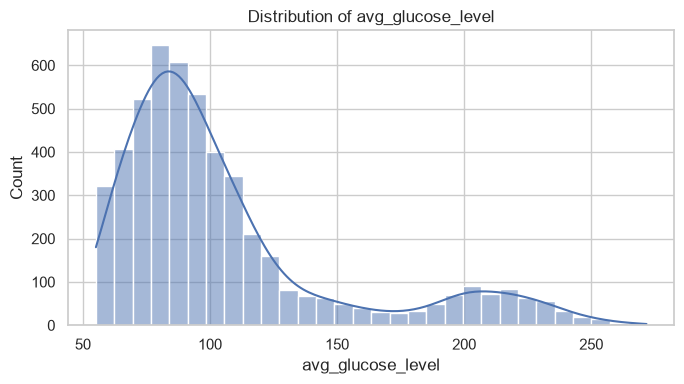

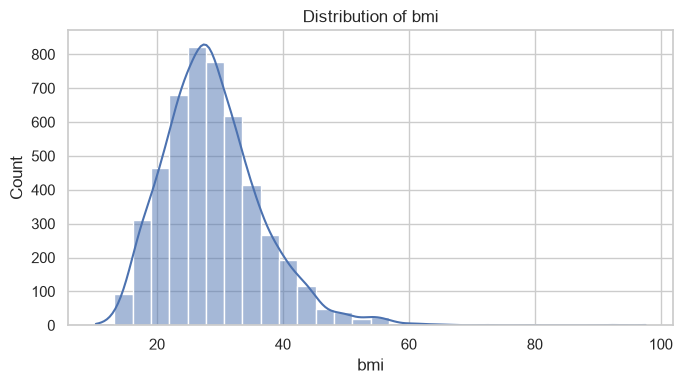

In [37]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{col}_distribution.png",
        dpi=300
    )

    plt.show()

    plt.close()

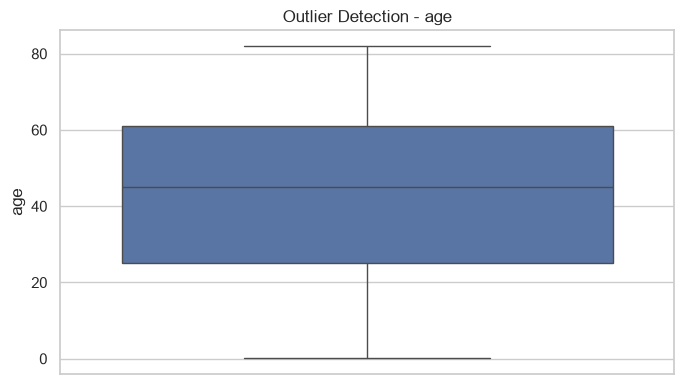

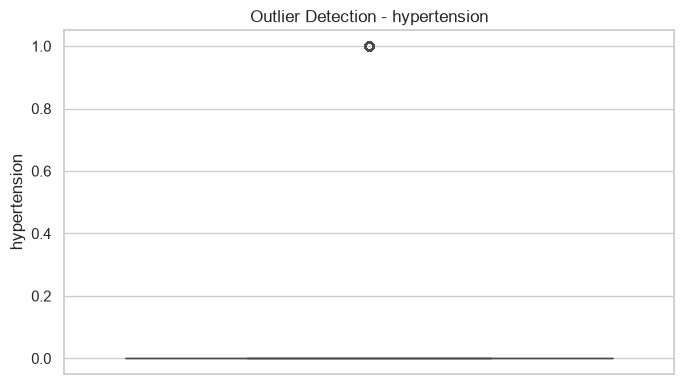

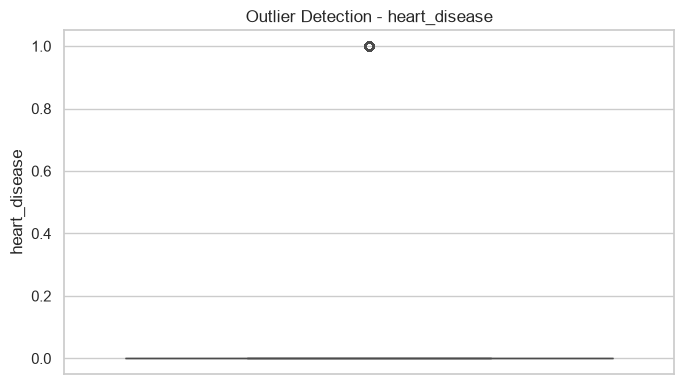

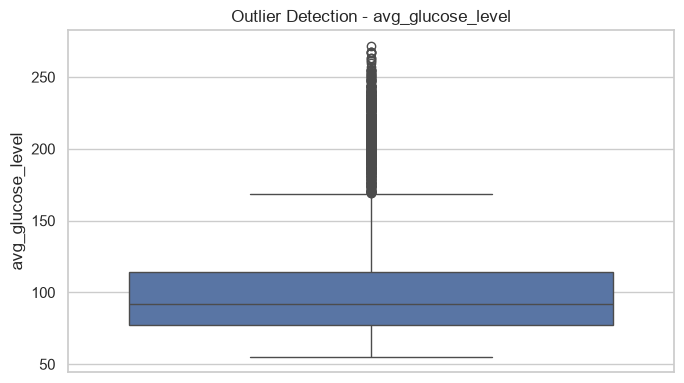

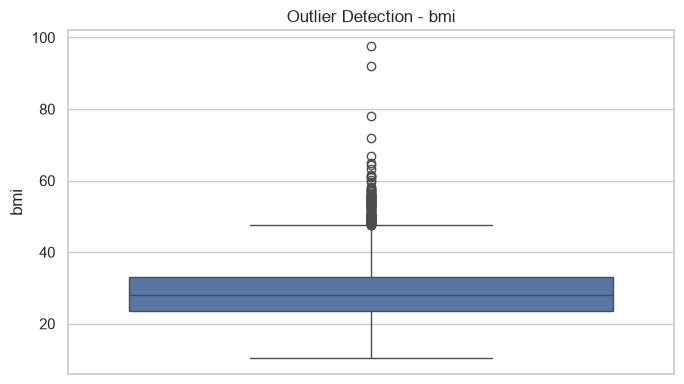

In [38]:
for col in numeric_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        y=col
    )

    plt.title(f"Outlier Detection - {col}")

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{col}_boxplot.png",
        dpi=300
    )

    plt.show()

    plt.close()

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


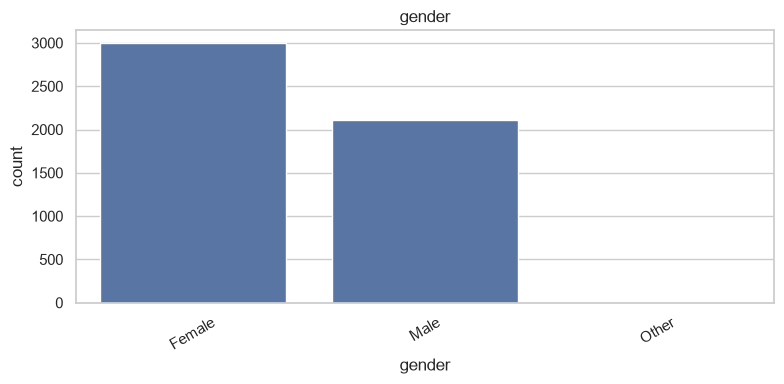

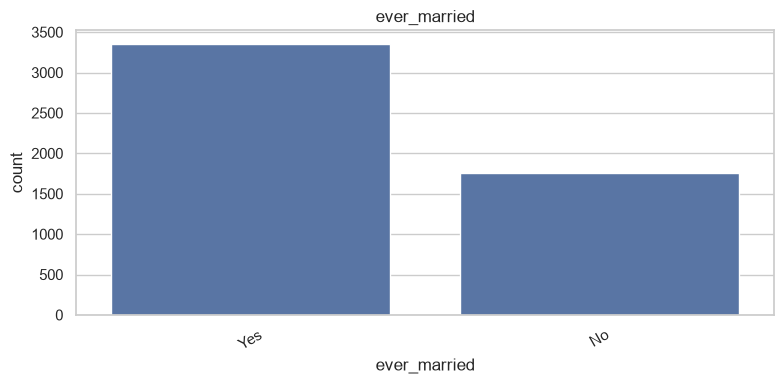

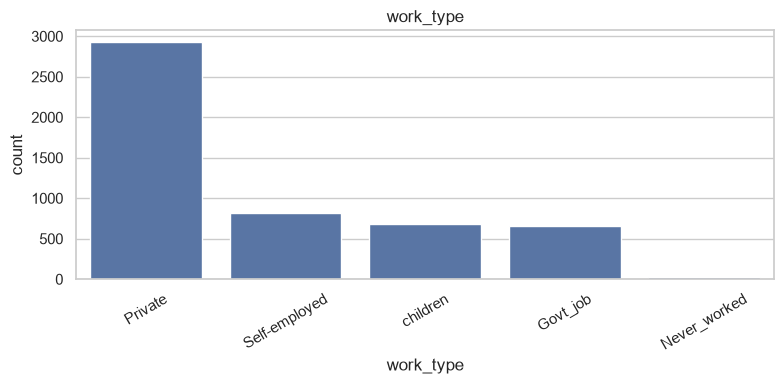

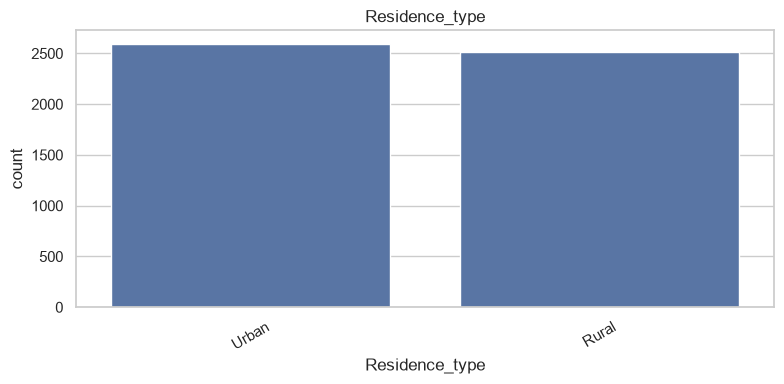

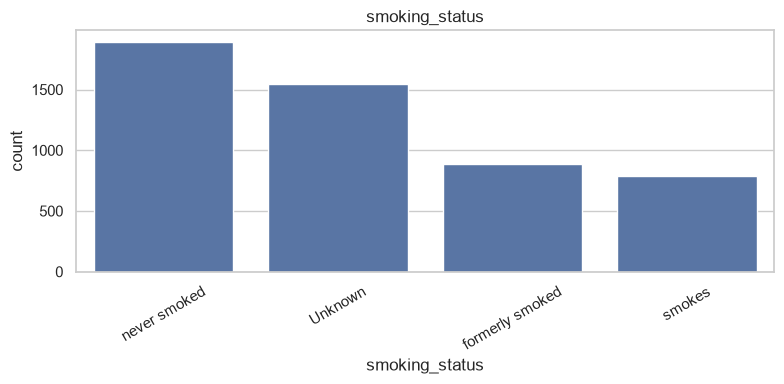

In [39]:
categorical_cols = [
    col
    for col in df.select_dtypes(
        include=["object", "string"]
    ).columns
]

print(categorical_cols)

for col in categorical_cols:

    plt.figure(figsize=(8,4))

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order
    )

    plt.xticks(rotation=30)

    plt.title(col)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{col}_countplot.png",
        dpi=300
    )

    plt.show()

    plt.close()

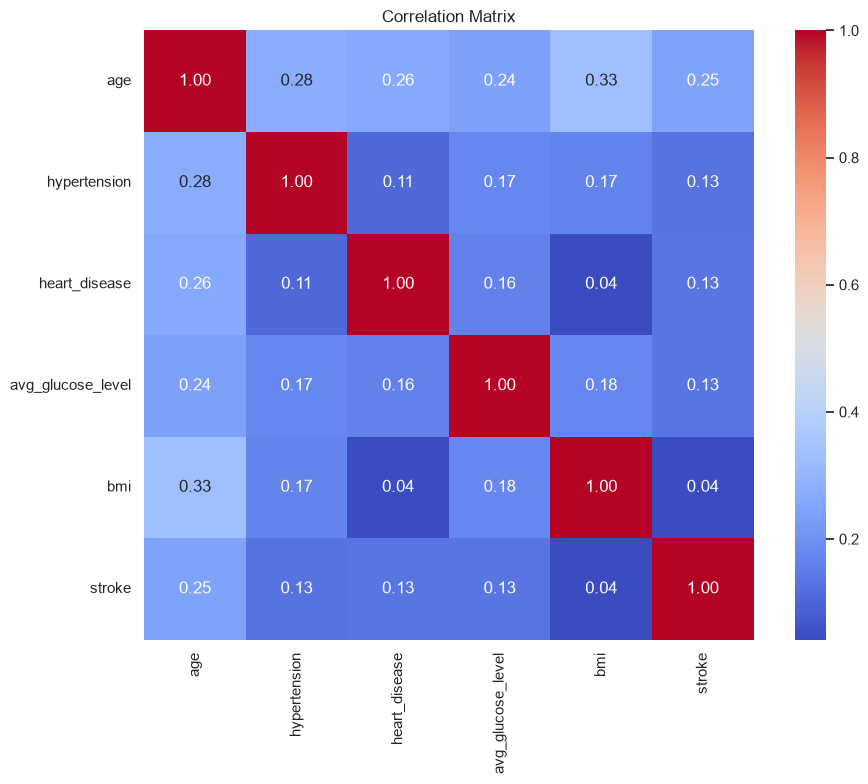

In [40]:
corr = df.drop(columns=[ID_COLUMN]).corr(
    numeric_only=True
)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "correlation_matrix.png",
    dpi=300
)

plt.show()

2026-07-07 14:51:31,352 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 14:51:31,355 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


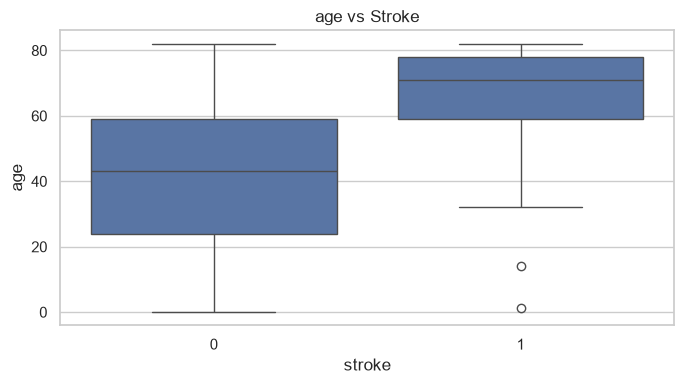

2026-07-07 14:51:31,548 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 14:51:31,553 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


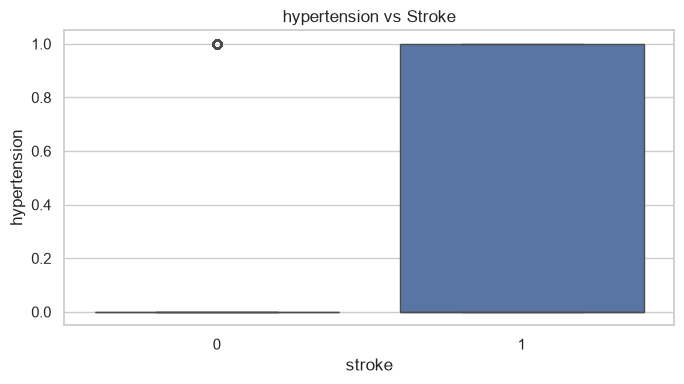

2026-07-07 14:51:31,736 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 14:51:31,741 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


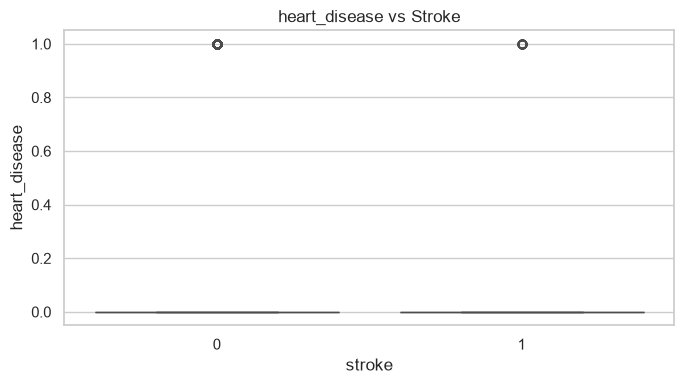

2026-07-07 14:51:31,918 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 14:51:31,918 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


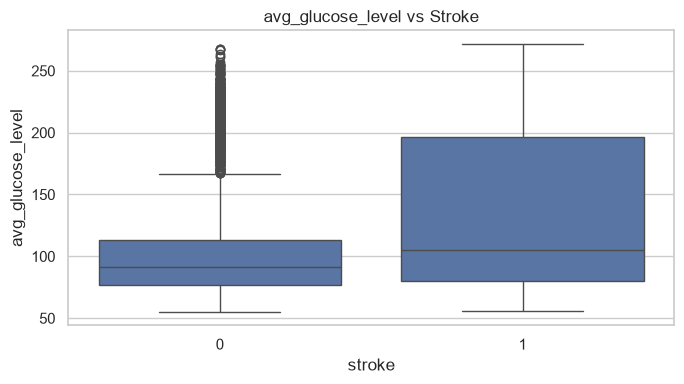

2026-07-07 14:51:32,102 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 14:51:32,102 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


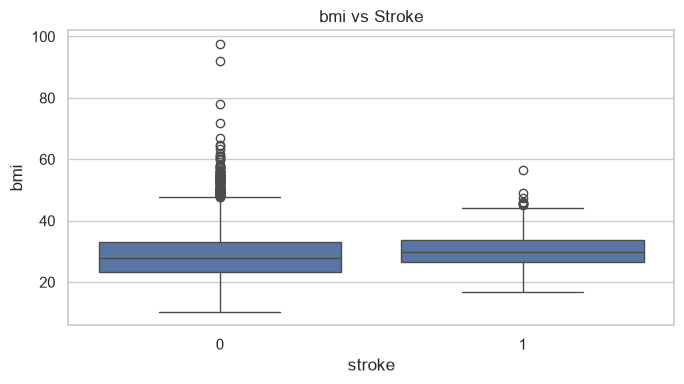

In [41]:
for col in numeric_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x=TARGET,
        y=col
    )

    plt.title(f"{col} vs Stroke")

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR /
        f"{col}_vs_stroke.png",
        dpi=300
    )

    plt.show()

    plt.close()

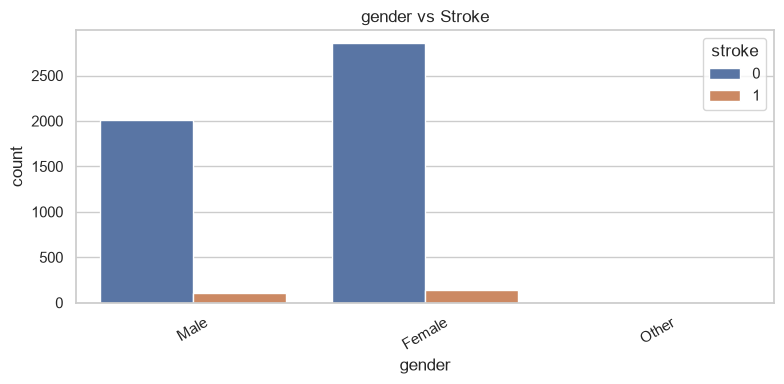

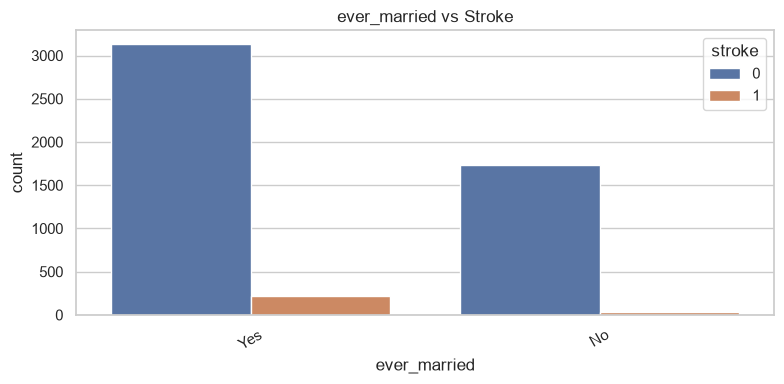

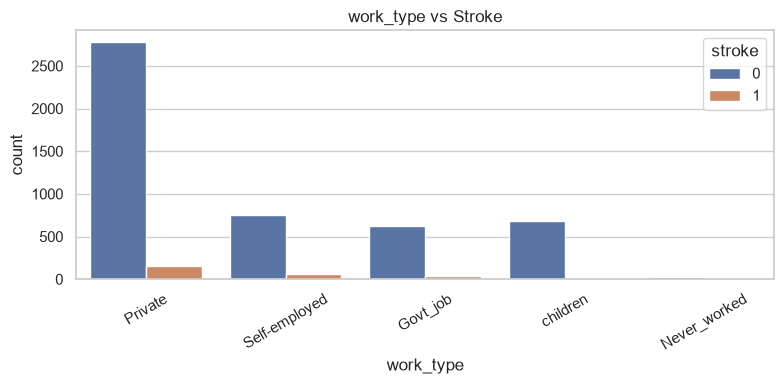

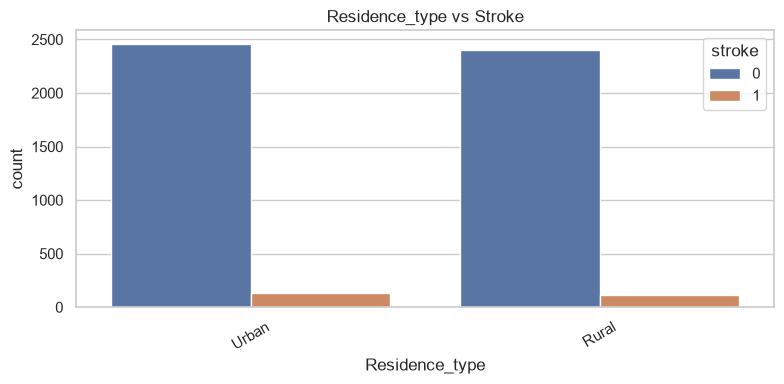

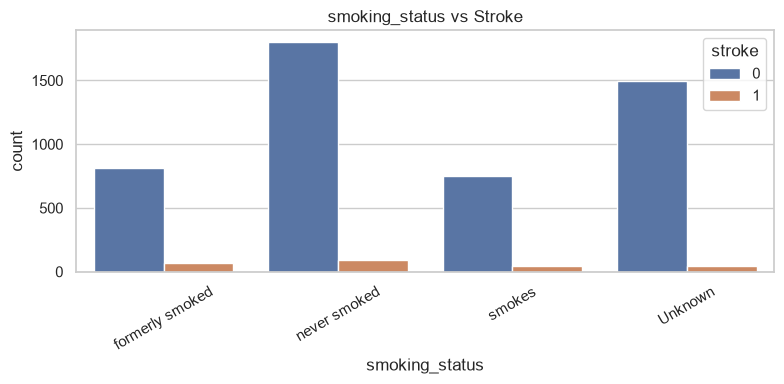

In [42]:
for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        hue=TARGET
    )

    plt.xticks(rotation=30)

    plt.title(f"{col} vs Stroke")

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR /
        f"{col}_vs_stroke.png",
        dpi=300
    )

    plt.show()

    plt.close()

In [43]:
skewness = (
    df[numeric_cols]
    .skew()
    .sort_values(
        ascending=False
    )
)

display(skewness.to_frame("Skewness"))

,Skewness
heart_disease,3.947244
hypertension,2.715392
avg_glucose_level,1.572284
bmi,1.055340
age,-0.137059


2026-07-07 14:51:33,628 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 14:51:33,640 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


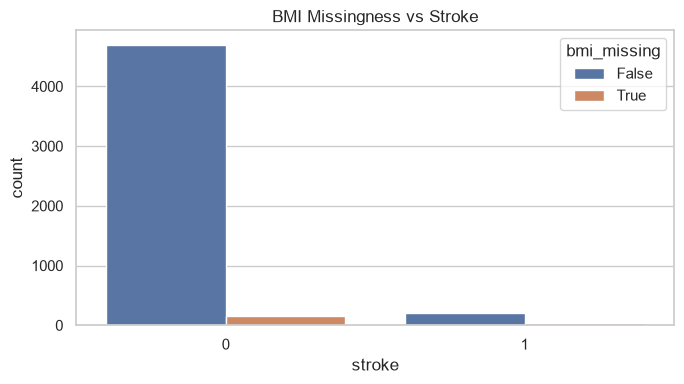

In [44]:
df["bmi_missing"] = df["bmi"].isna()

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="stroke",
    hue="bmi_missing"
)

plt.title("BMI Missingness vs Stroke")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "bmi_missing_vs_stroke.png",
    dpi=300
)

plt.show()

In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(df["stroke"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df["stroke"]
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.5256120139888911), np.int64(1): np.float64(10.261044176706827)}


In [46]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

encoded = df.copy()

for col in categorical_cols:
    encoded[col] = LabelEncoder().fit_transform(
        encoded[col]
    )

encoded["bmi"] = encoded["bmi"].fillna(
    encoded["bmi"].median()
)

X = encoded.drop(
    columns=["stroke", "id"]
)

y = encoded["stroke"]

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi = (
    pd.Series(
        mi,
        index=X.columns
    )
    .sort_values(
        ascending=False
    )
)

display(mi)

age                  0.040236
hypertension         0.012380
bmi                  0.010126
work_type            0.007873
ever_married         0.007631
avg_glucose_level    0.007067
heart_disease        0.006400
Residence_type       0.003611
smoking_status       0.002706
gender               0.000000
bmi_missing          0.000000
dtype: float64